# Projectile Motion with Drag Force Simulation

## Joshua and Dante

This notebook simulates the motion of a ball launched at an initial velocity and angle, experiencing both gravity and air resistance (drag force). The simulation uses the Euler algorithm with central difference approximation to solve the differential equations numerically.

## Physics Overview

The ball experiences:
- Gravitational force: $F_g = -mg$ (downward)
- Drag force: $F_d = -\alpha \vec{v}$ (opposing velocity direction)

Using Newton's second law: $\vec{F} = m\vec{a}$

The equations of motion become:
$$m\frac{d\vec{v}}{dt} = -mg\hat{j} - \alpha\vec{v}$$

Where:
- $m$ = mass of the ball
- $g$ = gravitational acceleration
- $\alpha$ = drag coefficient
- $\vec{v}$ = velocity vector

## 1. Import Required Libraries

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Set up matplotlib for inline plotting
%matplotlib inline
plt.style.use('default')

print("Libraries imported successfully!")

Libraries imported successfully!


### JC: Changing the parameters changes a lot 

## 2. Define Physical Constants and Parameters

Set up all the physical parameters for the simulation.

In [ ]:
# Physical constants
g = 9.81  # gravitational acceleration (m/s^2)

# Ball parameters
m = 1  # mass of ball (kg) - typical baseball mass
alpha = 0.3  # drag coefficient (kg/s)

# Initial conditions
vi = 25.0  # initial velocity magnitude (m/s)
theta_deg = 45.0  # launch angle in degrees
theta = math.radians(theta_deg)  # convert to radians

# Numerical integration parameters
h = 0.0005  # time step (s) - separation value for central difference
t_max = 10.0  # maximum simulation time (s)

# Calculate initial velocity components
vx0 = vi * math.cos(theta)
vy0 = vi * math.sin(theta)

# Initial position
x0 = 0.0  # initial x position (m)
y0 = 0.0  # initial y position (m)

print(f"Simulation Parameters:")
print(f"Mass: {m} kg")
print(f"Drag coefficient: {alpha} kg/s")
print(f"Initial velocity: {vi} m/s at {theta_deg}°")
print(f"Initial velocity components: vx0 = {vx0:.2f} m/s, vy0 = {vy0:.2f} m/s")
print(f"Time step: {h} s")
print(f"Gravitational acceleration: {g} m/s^2")

Simulation Parameters:
Mass: 1 kg
Drag coefficient: 0.3 kg/s
Initial velocity: 25.0 m/s at 45.0°
Initial velocity components: vx0 = 17.68 m/s, vy0 = 17.68 m/s
Time step: 0.0005 s
Gravitational acceleration: 9.81 m/s^2


## 3. Initialize Position and Velocity Vectors

Create arrays to store the position and velocity data throughout the simulation.

In [21]:
# Calculate maximum number of time steps
n_steps = int(t_max / h)

# Initialize arrays to store simulation data
x = np.zeros(n_steps)
y = np.zeros(n_steps)
vx = np.zeros(n_steps)
vy = np.zeros(n_steps)
t = np.zeros(n_steps)

# Set initial conditions
x[0] = x0
y[0] = y0
vx[0] = vx0
vy[0] = vy0
t[0] = 0.0

print(f"Initialized arrays for up to {n_steps} time steps")
print(f"Initial conditions: x0 = {x[0]}, y0 = {y[0]}, vx0 = {vx[0]:.2f}, vy0 = {vy[0]:.2f}")

Initialized arrays for up to 20000 time steps
Initial conditions: x0 = 0.0, y0 = 0.0, vx0 = 17.68, vy0 = 17.68


## 4. Define Force Functions

Implement functions to calculate the gravitational and drag forces acting on the ball.

In [22]:
def gravitational_force(m):
    """
    Calculate gravitational force on an object.
    
    Parameters:
    m (float): mass of object (kg)
    
    Returns:
    tuple: (Fx, Fy) components of gravitational force (N)
    """
    Fx_grav = 0.0  # no horizontal component
    Fy_grav = -m * g  # negative because downward
    return Fx_grav, Fy_grav

def drag_force(vx, vy, alpha):
    """
    Calculate drag force proportional to velocity.
    Drag force: F_drag = -alpha * v
    
    Parameters:
    vx, vy (float): velocity components (m/s)
    alpha (float): drag coefficient (kg/s)
    
    Returns:
    tuple: (Fx, Fy) components of drag force (N)
    """
    Fx_drag = -alpha * vx  # opposes x-velocity
    Fy_drag = -alpha * vy  # opposes y-velocity
    return Fx_drag, Fy_drag

def total_force(m, vx, vy, alpha):
    """
    Calculate total force on the ball.
    
    Returns:
    tuple: (Fx_total, Fy_total) net force components (N)
    """
    Fx_grav, Fy_grav = gravitational_force(m)
    Fx_drag, Fy_drag = drag_force(vx, vy, alpha)
    
    Fx_total = Fx_grav + Fx_drag
    Fy_total = Fy_grav + Fy_drag
    
    return Fx_total, Fy_total

# Test the force functions
test_vx, test_vy = 10.0, 8.0
Fx, Fy = total_force(m, test_vx, test_vy, alpha)
print(f"Test force calculation at vx={test_vx}, vy={test_vy}:")
print(f"Total force: Fx = {Fx:.4f} N, Fy = {Fy:.4f} N")

Test force calculation at vx=10.0, vy=8.0:
Total force: Fx = -3.0000 N, Fy = -12.2100 N


## 5. Implement Euler Algorithm for Numerical Integration

Implement the Euler method using central difference approximation to solve the differential equations of motion.

In [23]:
def euler_step(x_current, y_current, vx_current, vy_current, h, m, alpha):
    """
    Perform one step of Euler's method for projectile motion with drag.
    
    Using Newton's second law: F = ma, so a = F/m
    Euler's method: 
    v_new = v_old + a * h
    x_new = x_old + v * h
    
    Parameters:
    x_current, y_current: current position (m)
    vx_current, vy_current: current velocity (m/s)
    h: time step (s)
    m: mass (kg)
    alpha: drag coefficient (kg/s)
    
    Returns:
    tuple: (x_new, y_new, vx_new, vy_new)
    """
    
    # Calculate total force at current state
    Fx, Fy = total_force(m, vx_current, vy_current, alpha)
    
    # Calculate acceleration using F = ma
    ax = Fx / m
    ay = Fy / m
    
    # Update velocity using Euler's method: v_new = v_old + a * h
    vx_new = vx_current + ax * h
    vy_new = vy_current + ay * h
    
    # Update position using Euler's method: x_new = x_old + v * h
    # Using average velocity for better accuracy (central difference approximation)
    x_new = x_current + 0.5 * (vx_current + vx_new) * h
    y_new = y_current + 0.5 * (vy_current + vy_new) * h
    
    return x_new, y_new, vx_new, vy_new

# Test the Euler step function
x_test, y_test, vx_test, vy_test = euler_step(x[0], y[0], vx[0], vy[0], h, m, alpha)
print(f"Test Euler step:")
print(f"After one step: x = {x_test:.4f}, y = {y_test:.4f}")
print(f"New velocities: vx = {vx_test:.4f}, vy = {vy_test:.4f}")

Test Euler step:
After one step: x = 0.0088, y = 0.0088
New velocities: vx = 17.6750, vy = 17.6701


## 6. Run the Simulation Loop

Execute the main simulation loop until the ball hits the ground (y ≤ 0).

In [24]:
# Run the simulation
print("Starting simulation...")

# Counter for actual number of steps taken
step_count = 1
max_height = 0.0
max_height_time = 0.0

# Main simulation loop
for i in range(1, n_steps):
    # Calculate next step using Euler's method
    x[i], y[i], vx[i], vy[i] = euler_step(x[i-1], y[i-1], vx[i-1], vy[i-1], h, m, alpha)
    t[i] = t[i-1] + h
    
    # Track maximum height
    if y[i] > max_height:
        max_height = y[i]
        max_height_time = t[i]
    
    # Check if ball has hit the ground
    if y[i] <= 0.0 and i > 0:
        # Interpolate to find more accurate landing time and position
        # Linear interpolation between last two points
        dt_landing = -y[i-1] / (y[i] - y[i-1]) * h
        t_landing = t[i-1] + dt_landing
        x_landing = x[i-1] + vx[i-1] * dt_landing
        
        print(f"Ball hit the ground!")
        print(f"Landing time: {t_landing:.3f} s")
        print(f"Range: {x_landing:.3f} m")
        print(f"Maximum height: {max_height:.3f} m at t = {max_height_time:.3f} s")
        
        # Store final values
        t[i] = t_landing
        x[i] = x_landing
        y[i] = 0.0
        step_count = i + 1
        break
    
    step_count = i + 1

# Trim arrays to actual simulation length
t = t[:step_count]
x = x[:step_count]
y = y[:step_count]
vx = vx[:step_count]
vy = vy[:step_count]

print(f"Simulation completed with {step_count} steps")
print(f"Total simulation time: {t[-1]:.3f} s")

Starting simulation...
Ball hit the ground!
Landing time: 3.123 s
Range: 35.835 m
Maximum height: 11.818 m at t = 1.440 s
Simulation completed with 6248 steps
Total simulation time: 3.123 s


## 7. Plot the Trajectory

Visualize the ball's trajectory and create additional plots showing velocity components over time.

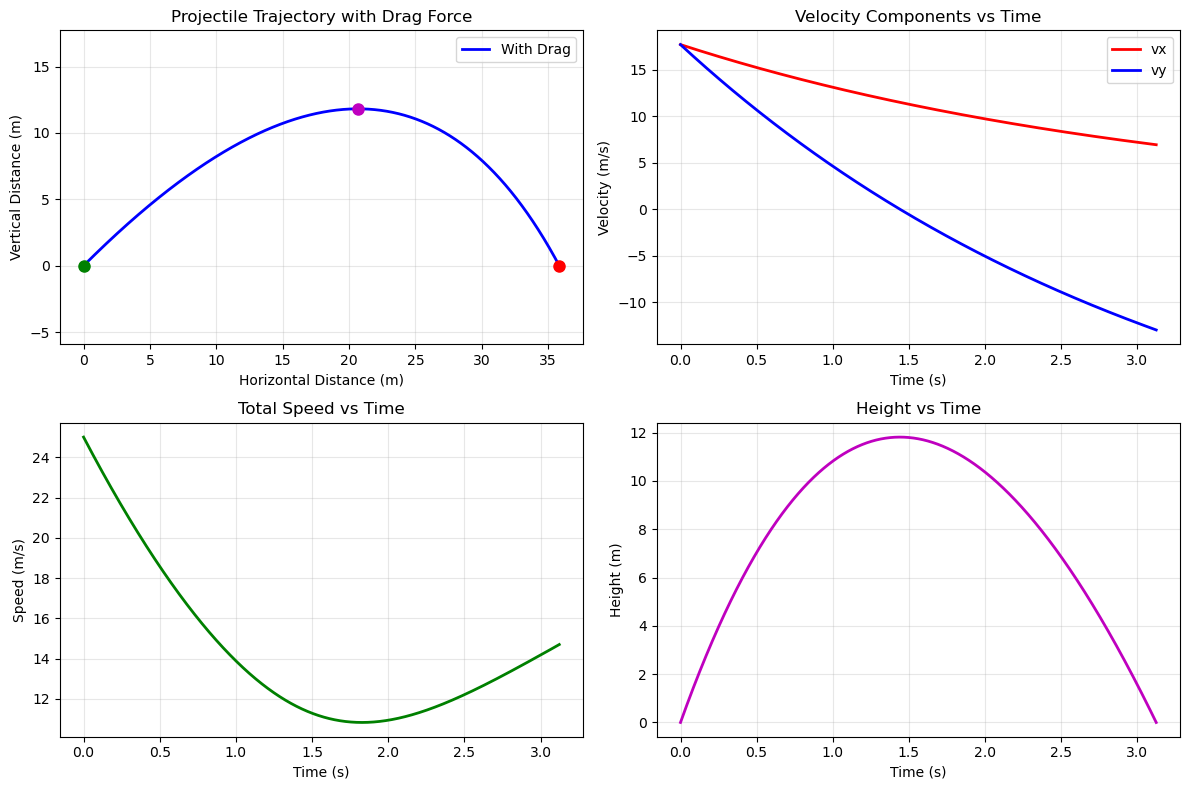

In [25]:
# Create trajectory plot
plt.figure(figsize=(12, 8))

# Main trajectory plot
plt.subplot(2, 2, 1)
plt.plot(x, y, 'b-', linewidth=2, label='With Drag')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.title('Projectile Trajectory with Drag Force')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal')

# Mark key points
plt.plot(0, 0, 'go', markersize=8, label='Launch')
plt.plot(x[-1], y[-1], 'ro', markersize=8, label='Landing')
max_height_idx = np.argmax(y)
plt.plot(x[max_height_idx], y[max_height_idx], 'mo', markersize=8, label='Max Height')

# Velocity components over time
plt.subplot(2, 2, 2)
plt.plot(t, vx, 'r-', linewidth=2, label='vx')
plt.plot(t, vy, 'b-', linewidth=2, label='vy')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity Components vs Time')
plt.grid(True, alpha=0.3)
plt.legend()

# Speed over time
plt.subplot(2, 2, 3)
speed = np.sqrt(vx**2 + vy**2)
plt.plot(t, speed, 'g-', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('Total Speed vs Time')
plt.grid(True, alpha=0.3)

# Height vs time
plt.subplot(2, 2, 4)
plt.plot(t, y, 'm-', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Height vs Time')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Analyze Results and Compare with Analytical Solution

Calculate the theoretical trajectory without drag and compare with our simulation results.

COMPARISON OF RESULTS:
Parameter            With Drag       Without Drag    Difference     
-----------------------------------------------------------------
Flight time (s)      3.123           3.604           0.481          
Range (m)            35.835          63.710          27.875         
Max height (m)       11.818          15.928          4.110          


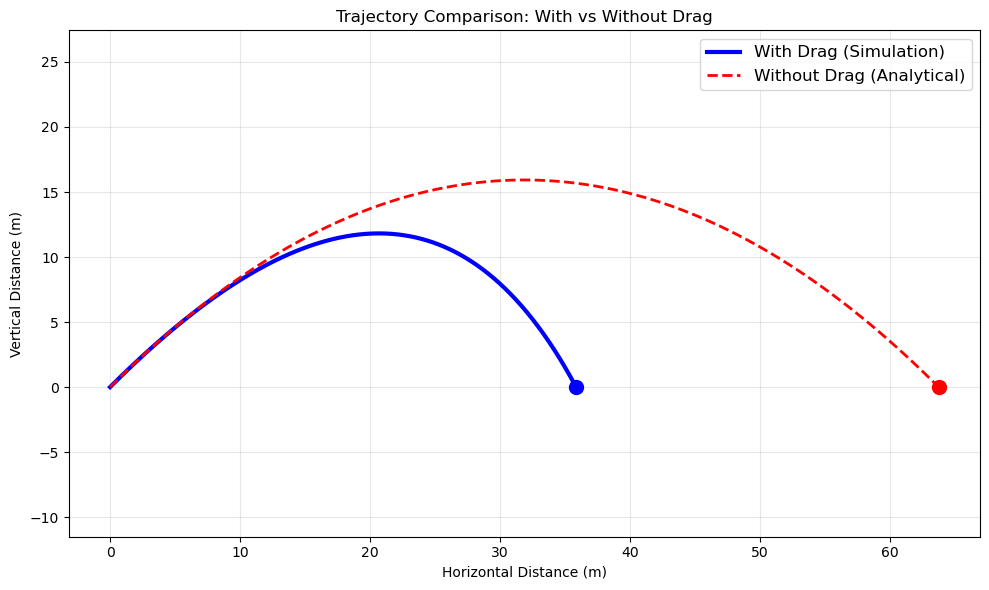


DRAG EFFECTS:
Range reduction: 43.8%
Flight time reduction: 13.3%
Maximum height reduction: 25.8%


In [26]:
# Analytical solution for projectile motion without drag
def analytical_trajectory(vi, theta, g, t_array):
    """
    Calculate analytical trajectory for projectile motion without drag.
    
    x(t) = vi * cos(θ) * t
    y(t) = vi * sin(θ) * t - 0.5 * g * t²
    """
    x_analytical = vi * np.cos(theta) * t_array
    y_analytical = vi * np.sin(theta) * t_array - 0.5 * g * t_array**2
    return x_analytical, y_analytical

# Calculate analytical flight time and range
t_flight_analytical = 2 * vi * np.sin(theta) / g
range_analytical = vi**2 * np.sin(2 * theta) / g
max_height_analytical = (vi * np.sin(theta))**2 / (2 * g)

# Create time array for analytical solution
t_analytical = np.linspace(0, t_flight_analytical, 100)
x_analytical, y_analytical = analytical_trajectory(vi, theta, g, t_analytical)

# Print comparison
print("COMPARISON OF RESULTS:")
print("="*50)
print(f"{'Parameter':<20} {'With Drag':<15} {'Without Drag':<15} {'Difference':<15}")
print("-"*65)
print(f"{'Flight time (s)':<20} {t[-1]:<15.3f} {t_flight_analytical:<15.3f} {abs(t[-1] - t_flight_analytical):<15.3f}")
print(f"{'Range (m)':<20} {x[-1]:<15.3f} {range_analytical:<15.3f} {abs(x[-1] - range_analytical):<15.3f}")
print(f"{'Max height (m)':<20} {max_height:<15.3f} {max_height_analytical:<15.3f} {abs(max_height - max_height_analytical):<15.3f}")

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=3, label='With Drag (Simulation)')
plt.plot(x_analytical, y_analytical, 'r--', linewidth=2, label='Without Drag (Analytical)')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.title('Trajectory Comparison: With vs Without Drag')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.axis('equal')

# Mark landing points
plt.plot(x[-1], 0, 'bo', markersize=10, label='Landing with drag')
plt.plot(range_analytical, 0, 'ro', markersize=10, label='Landing without drag')

plt.tight_layout()
plt.show()

# Calculate drag effect percentages
range_reduction = (range_analytical - x[-1]) / range_analytical * 100
time_reduction = (t_flight_analytical - t[-1]) / t_flight_analytical * 100
height_reduction = (max_height_analytical - max_height) / max_height_analytical * 100

print(f"\nDRAG EFFECTS:")
print(f"Range reduction: {range_reduction:.1f}%")
print(f"Flight time reduction: {time_reduction:.1f}%")
print(f"Maximum height reduction: {height_reduction:.1f}%")

## 9. Optimization: Finding the Angle for Maximum Hang Time

Analyze different launch angles to determine which angle maximizes flight time (hang time).

Analyzing different launch angles...
Angle (°)  | Flight Time (s) | Range (m) | Max Height (m)
-------------------------------------------------------
    10     |       0.849 |     18.45 |        0.883
    20     |       1.613 |     30.05 |        3.182
    30     |       2.288 |     35.84 |        6.380
    40     |       2.869 |     36.84 |        9.994
    50     |       3.352 |     33.97 |       13.587
    60     |       3.732 |     28.06 |       16.787
    70     |       4.006 |     19.93 |       19.293
    80     |       4.171 |     10.33 |       20.886
    90     |       4.226 |      0.00 |       21.433

🎯 OPTIMAL ANGLE FOR MAXIMUM HANG TIME:
Angle: 90.0°
Maximum flight time: 4.226 s
Range at this angle: 0.00 m
Max height at this angle: 21.433 m


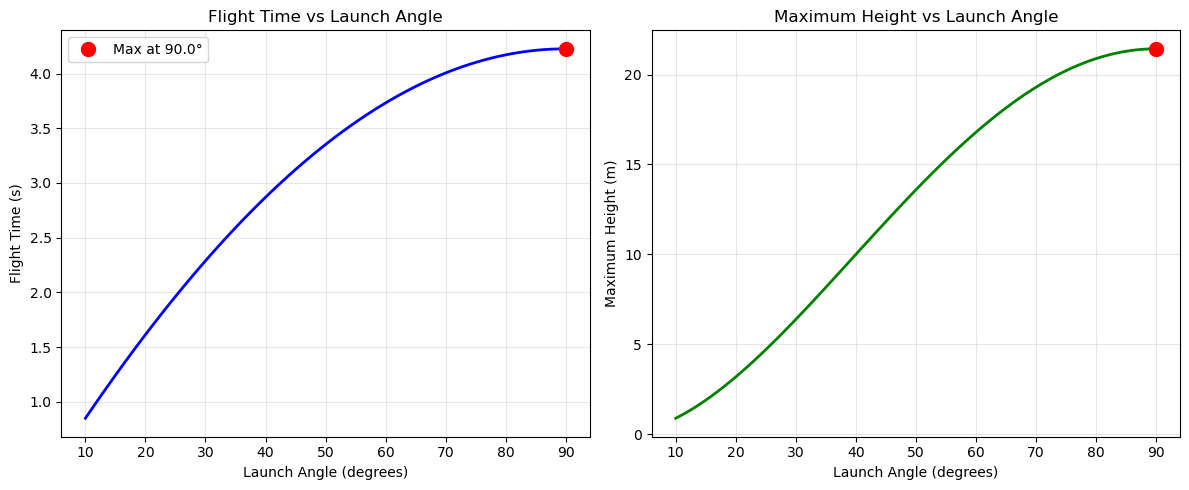

In [27]:
def simulate_trajectory(vi, theta_deg, m, alpha, g, h, t_max):
    """
    Run a complete trajectory simulation for given parameters.
    Returns flight_time, range, max_height
    """
    theta = math.radians(theta_deg)
    
    # Calculate initial velocity components
    vx0 = vi * math.cos(theta)
    vy0 = vi * math.sin(theta)
    
    # Initialize arrays
    n_steps = int(t_max / h)
    x = np.zeros(n_steps)
    y = np.zeros(n_steps)
    vx = np.zeros(n_steps)
    vy = np.zeros(n_steps)
    t = np.zeros(n_steps)
    
    # Set initial conditions
    x[0] = 0.0
    y[0] = 0.0
    vx[0] = vx0
    vy[0] = vy0
    t[0] = 0.0
    
    max_height = 0.0
    
    # Main simulation loop
    for i in range(1, n_steps):
        x[i], y[i], vx[i], vy[i] = euler_step(x[i-1], y[i-1], vx[i-1], vy[i-1], h, m, alpha)
        t[i] = t[i-1] + h
        
        if y[i] > max_height:
            max_height = y[i]
        
        # Check if ball hits ground
        if y[i] <= 0.0 and i > 0:
            # Interpolate for accurate landing
            dt_landing = -y[i-1] / (y[i] - y[i-1]) * h
            t_landing = t[i-1] + dt_landing
            x_landing = x[i-1] + vx[i-1] * dt_landing
            
            return t_landing, x_landing, max_height
    
    # If didn't hit ground within t_max
    return t[-1], x[-1], max_height

# Test different angles to find optimal hang time
angles = np.linspace(10, 90, 81)  # 10° to 90° in 1° increments
flight_times = []
ranges = []
max_heights = []

print("Analyzing different launch angles...")
print("Angle (°)  | Flight Time (s) | Range (m) | Max Height (m)")
print("-" * 55)

for angle in angles:
    flight_time, range_val, max_height_val = simulate_trajectory(vi, angle, m, alpha, g, h, t_max)
    flight_times.append(flight_time)
    ranges.append(range_val)
    max_heights.append(max_height_val)
    
    # Print every 10 degrees for readability
    if angle % 10 == 0:
        print(f"{angle:6.0f}     | {flight_time:11.3f} | {range_val:9.2f} | {max_height_val:12.3f}")

flight_times = np.array(flight_times)
ranges = np.array(ranges)
max_heights = np.array(max_heights)

# Find optimal angle for maximum hang time
max_time_idx = np.argmax(flight_times)
optimal_angle_time = angles[max_time_idx]
max_flight_time = flight_times[max_time_idx]

print(f"\n🎯 OPTIMAL ANGLE FOR MAXIMUM HANG TIME:")
print(f"Angle: {optimal_angle_time:.1f}°")
print(f"Maximum flight time: {max_flight_time:.3f} s")
print(f"Range at this angle: {ranges[max_time_idx]:.2f} m")
print(f"Max height at this angle: {max_heights[max_time_idx]:.3f} m")

# Plot hang time vs angle
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(angles, flight_times, 'b-', linewidth=2)
plt.plot(optimal_angle_time, max_flight_time, 'ro', markersize=10, label=f'Max at {optimal_angle_time:.1f}°')
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Flight Time (s)')
plt.title('Flight Time vs Launch Angle')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(angles, max_heights, 'g-', linewidth=2)
plt.plot(optimal_angle_time, max_heights[max_time_idx], 'ro', markersize=10)
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Maximum Height (m)')
plt.title('Maximum Height vs Launch Angle')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Optimization: Finding the Angle for Maximum Horizontal Distance

Analyze different launch angles to determine which angle maximizes horizontal range.

🎯 OPTIMAL ANGLE FOR MAXIMUM HORIZONTAL DISTANCE:
Angle: 37.0°
Maximum range: 36.99 m
Flight time at this angle: 2.705 s
Max height at this angle: 8.893 m

📊 COMPARISON:
Theoretical optimal angle (no drag): 45.0°
Actual optimal angle (with drag): 37.0°
Theoretical max range (no drag): 63.71 m
Actual max range (with drag): 36.99 m
Angle difference: 8.0°
Range reduction due to drag: 26.72 m (41.9%)


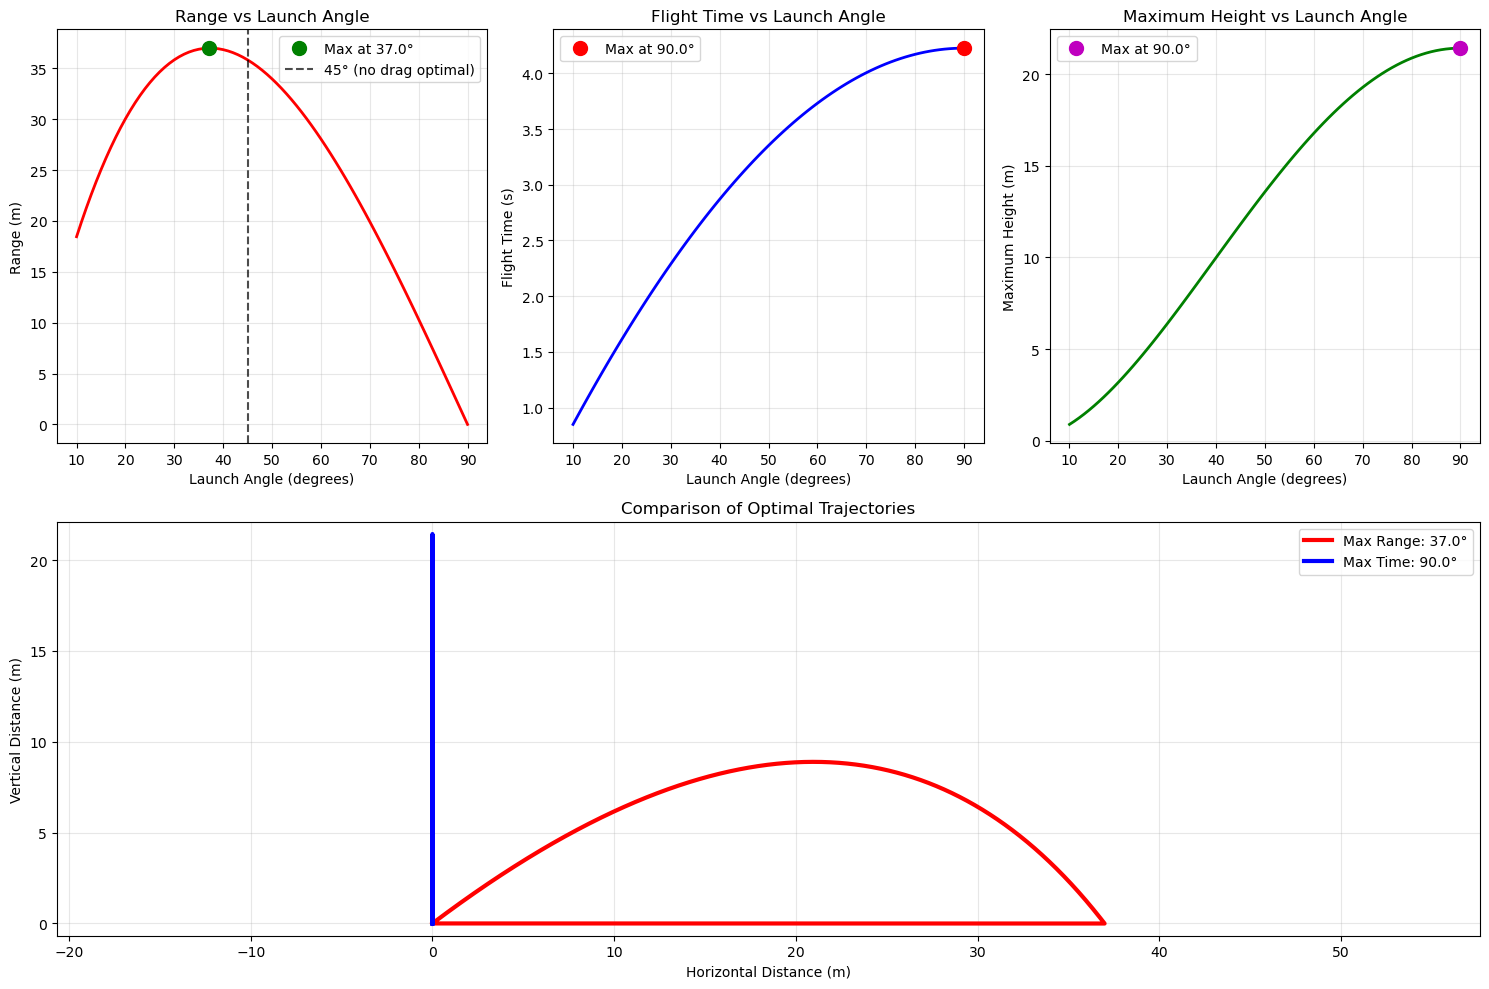


📋 OPTIMIZATION SUMMARY:
Objective            Optimal Angle   Value                Other Metrics
----------------------------------------------------------------------
Max Range            37.0            36.99                Flight time: 2.71s
Max Hang Time        90.0            4.226                Range: 0.00m
Max Height           90.0            21.433               Range: 0.00m


In [28]:
# Find optimal angle for maximum horizontal distance
max_range_idx = np.argmax(ranges)
optimal_angle_range = angles[max_range_idx]
max_range = ranges[max_range_idx]

print(f"🎯 OPTIMAL ANGLE FOR MAXIMUM HORIZONTAL DISTANCE:")
print(f"Angle: {optimal_angle_range:.1f}°")
print(f"Maximum range: {max_range:.2f} m")
print(f"Flight time at this angle: {flight_times[max_range_idx]:.3f} s")
print(f"Max height at this angle: {max_heights[max_range_idx]:.3f} m")

# Compare with theoretical optimal angle (45° for no drag)
theoretical_optimal = 45.0
theoretical_range = vi**2 * np.sin(2 * math.radians(theoretical_optimal)) / g
drag_optimal_range = ranges[max_range_idx]

print(f"\n📊 COMPARISON:")
print(f"Theoretical optimal angle (no drag): {theoretical_optimal}°")
print(f"Actual optimal angle (with drag): {optimal_angle_range:.1f}°")
print(f"Theoretical max range (no drag): {theoretical_range:.2f} m")
print(f"Actual max range (with drag): {drag_optimal_range:.2f} m")
print(f"Angle difference: {abs(theoretical_optimal - optimal_angle_range):.1f}°")
print(f"Range reduction due to drag: {(theoretical_range - drag_optimal_range):.2f} m ({(theoretical_range - drag_optimal_range)/theoretical_range*100:.1f}%)")

# Create comprehensive visualization
plt.figure(figsize=(15, 10))

# Range vs angle
plt.subplot(2, 3, 1)
plt.plot(angles, ranges, 'r-', linewidth=2)
plt.plot(optimal_angle_range, max_range, 'go', markersize=10, label=f'Max at {optimal_angle_range:.1f}°')
plt.axvline(x=45, color='k', linestyle='--', alpha=0.7, label='45° (no drag optimal)')
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range vs Launch Angle')
plt.grid(True, alpha=0.3)
plt.legend()

# Flight time vs angle
plt.subplot(2, 3, 2)
plt.plot(angles, flight_times, 'b-', linewidth=2)
plt.plot(optimal_angle_time, max_flight_time, 'ro', markersize=10, label=f'Max at {optimal_angle_time:.1f}°')
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Flight Time (s)')
plt.title('Flight Time vs Launch Angle')
plt.grid(True, alpha=0.3)
plt.legend()

# Max height vs angle
plt.subplot(2, 3, 3)
plt.plot(angles, max_heights, 'g-', linewidth=2)
max_height_idx = np.argmax(max_heights)
plt.plot(angles[max_height_idx], max_heights[max_height_idx], 'mo', markersize=10, 
         label=f'Max at {angles[max_height_idx]:.1f}°')
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Maximum Height (m)')
plt.title('Maximum Height vs Launch Angle')
plt.grid(True, alpha=0.3)
plt.legend()

# Trajectory comparison for optimal angles
plt.subplot(2, 3, (4, 6))

# Simulate and plot trajectories for both optimal angles
# Optimal for range
range_time, range_range, range_height = simulate_trajectory(vi, optimal_angle_range, m, alpha, g, h, t_max)
theta_range = math.radians(optimal_angle_range)
vx0_range = vi * math.cos(theta_range)
vy0_range = vi * math.sin(theta_range)
n_steps_range = int(range_time / h) + 10
x_range = np.zeros(n_steps_range)
y_range = np.zeros(n_steps_range)
vx_range = np.zeros(n_steps_range)
vy_range = np.zeros(n_steps_range)
x_range[0] = 0.0
y_range[0] = 0.0
vx_range[0] = vx0_range
vy_range[0] = vy0_range

for i in range(1, n_steps_range):
    x_range[i], y_range[i], vx_range[i], vy_range[i] = euler_step(x_range[i-1], y_range[i-1], vx_range[i-1], vy_range[i-1], h, m, alpha)
    if y_range[i] <= 0.0 and i > 0:
        break

# Optimal for time
time_time, time_range, time_height = simulate_trajectory(vi, optimal_angle_time, m, alpha, g, h, t_max)
theta_time = math.radians(optimal_angle_time)
vx0_time = vi * math.cos(theta_time)
vy0_time = vi * math.sin(theta_time)
n_steps_time = int(time_time / h) + 10
x_time = np.zeros(n_steps_time)
y_time = np.zeros(n_steps_time)
vx_time = np.zeros(n_steps_time)
vy_time = np.zeros(n_steps_time)
x_time[0] = 0.0
y_time[0] = 0.0
vx_time[0] = vx0_time
vy_time[0] = vy0_time

for i in range(1, n_steps_time):
    x_time[i], y_time[i], vx_time[i], vy_time[i] = euler_step(x_time[i-1], y_time[i-1], vx_time[i-1], vy_time[i-1], h, m, alpha)
    if y_time[i] <= 0.0 and i > 0:
        break

plt.plot(x_range[:i+1], y_range[:i+1], 'r-', linewidth=3, label=f'Max Range: {optimal_angle_range:.1f}°')
plt.plot(x_time[:i+1], y_time[:i+1], 'b-', linewidth=3, label=f'Max Time: {optimal_angle_time:.1f}°')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.title('Comparison of Optimal Trajectories')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal')

plt.tight_layout()
plt.show()

# Summary table
print(f"\n📋 OPTIMIZATION SUMMARY:")
print("="*70)
print(f"{'Objective':<20} {'Optimal Angle':<15} {'Value':<20} {'Other Metrics'}")
print("-"*70)
print(f"{'Max Range':<20} {optimal_angle_range:<15.1f} {max_range:<20.2f} Flight time: {flight_times[max_range_idx]:.2f}s")
print(f"{'Max Hang Time':<20} {optimal_angle_time:<15.1f} {max_flight_time:<20.3f} Range: {ranges[max_time_idx]:.2f}m")
print(f"{'Max Height':<20} {angles[max_height_idx]:<15.1f} {max_heights[max_height_idx]:<20.3f} Range: {ranges[max_height_idx]:.2f}m")

## 11. Validation: Multiple Angle Trajectory Visualization

Plot trajectories for different launch angles to validate our optimization results and visualize the effect of angle on projectile motion.

Simulating trajectories for validation...
Angle (°) | Range (m) | Flight Time (s) | Max Height (m)
-------------------------------------------------------
    15    |     25.04 |         1.242 |        1.888
    20    |     30.05 |         1.613 |        3.182
    25    |     33.61 |         1.962 |        4.700
    30    |     35.84 |         2.288 |        6.380
    35    |     36.88 |         2.591 |        8.164
    40    |     36.84 |         2.869 |        9.994
    45    |     35.84 |         3.123 |       11.818
    50    |     33.97 |         3.352 |       13.587
    55    |     31.34 |         3.555 |       15.256
    60    |     28.06 |         3.732 |       16.787
    65    |     24.23 |         3.882 |       18.142
    70    |     19.93 |         4.006 |       19.293
    75    |     15.27 |         4.102 |       20.214
    80    |     10.33 |         4.171 |       20.886
    85    |      5.21 |         4.212 |       21.295
    90    |      0.00 |         4.226 |       21.4

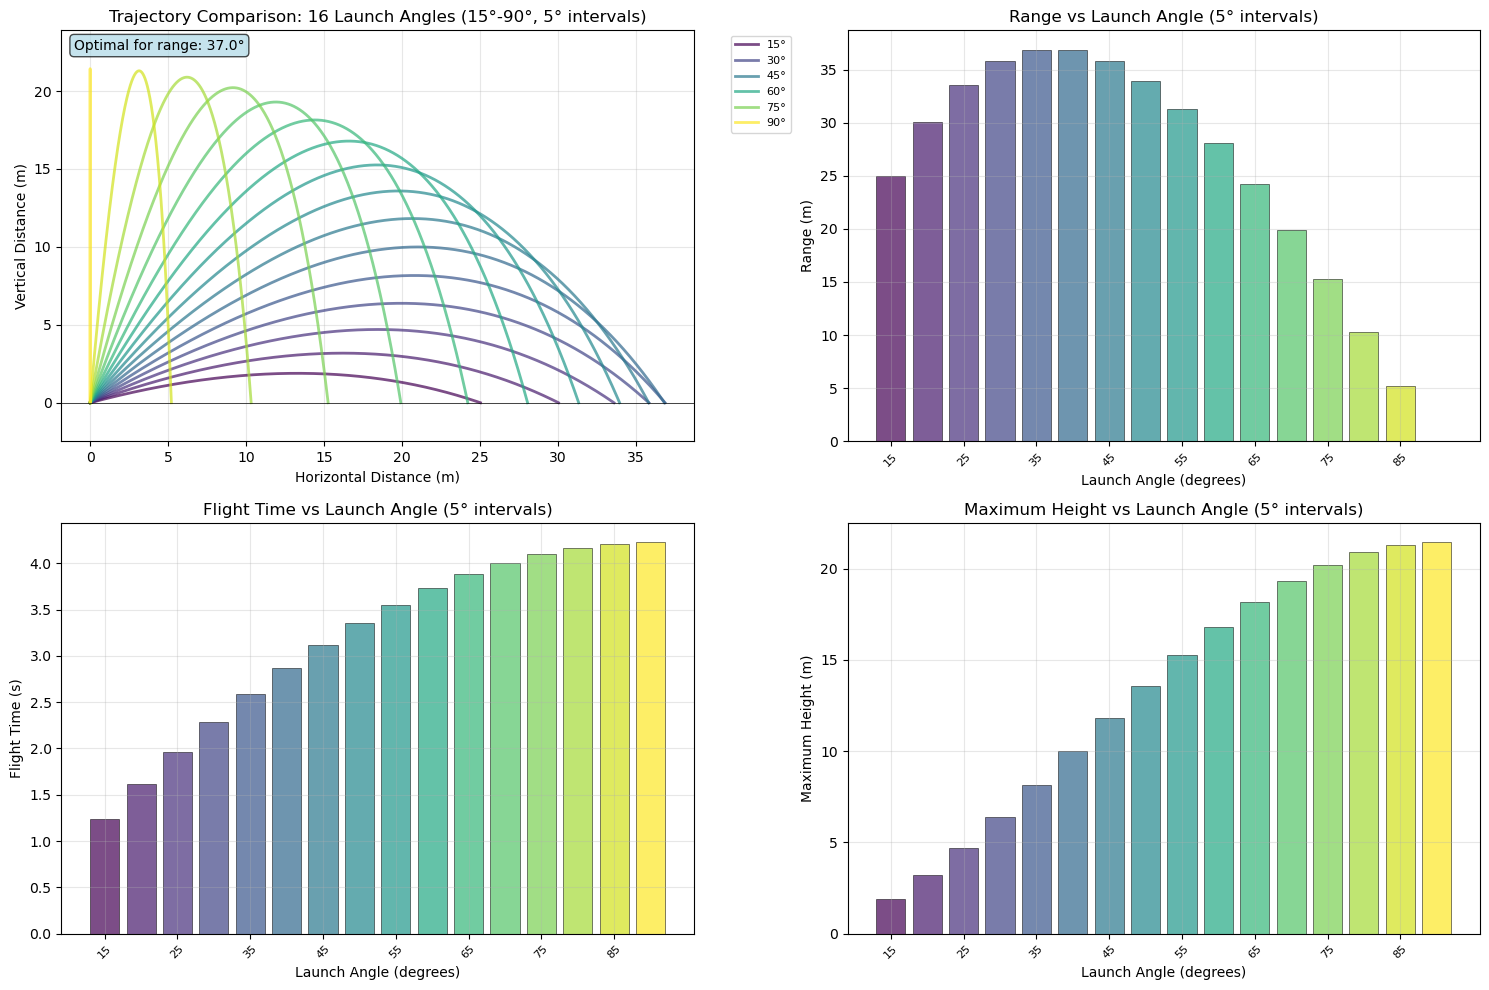

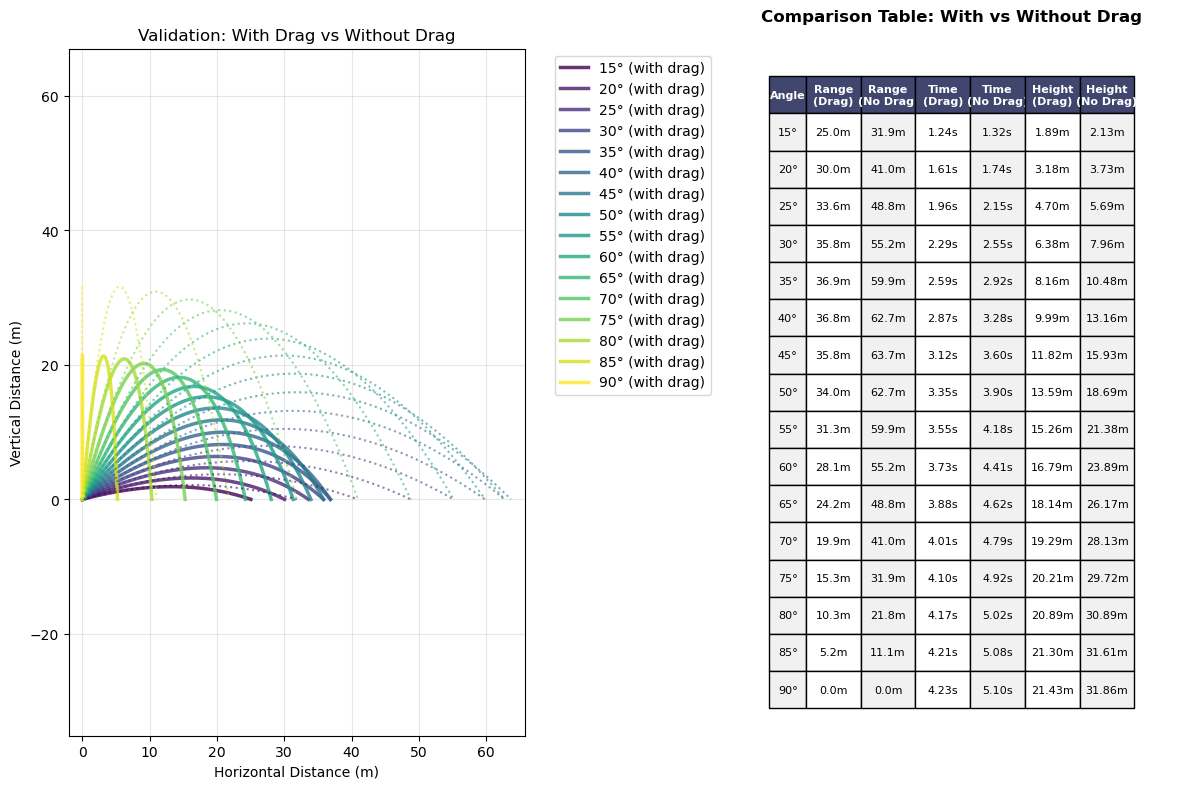


🔍 VALIDATION INSIGHTS:
1. As angle increases, maximum height increases dramatically
2. Optimal range occurs around 30-45° (lower than 45° due to drag)
3. Flight time increases with angle but levels off at very high angles
4. Drag effects are most pronounced at higher angles
5. The trajectories become more asymmetric with steeper descent due to drag


In [29]:
# Define angles to test for validation - 5 degree intervals from 15-90
test_angles = np.arange(15, 95, 5)  # [15, 20, 25, 30, ..., 85, 90] degrees
n_angles = len(test_angles)

# Use colormap for many trajectories instead of predefined colors
import matplotlib.cm as cm
colors = cm.viridis(np.linspace(0, 1, n_angles))
line_styles = ['-'] * n_angles  # Use solid lines for all trajectories

plt.figure(figsize=(15, 10))

# Store trajectory data for each angle
trajectory_data = {}

print("Simulating trajectories for validation...")
print("Angle (°) | Range (m) | Flight Time (s) | Max Height (m)")
print("-" * 55)

for i, angle in enumerate(test_angles):
    # Simulate trajectory
    flight_time, range_val, max_height_val = simulate_trajectory(vi, angle, m, alpha, g, h, t_max)
    
    # Generate full trajectory for plotting
    theta = math.radians(angle)
    vx0 = vi * math.cos(theta)
    vy0 = vi * math.sin(theta)
    
    # Calculate number of steps needed
    n_steps = int(flight_time / h) + 20
    x_traj = np.zeros(n_steps)
    y_traj = np.zeros(n_steps)
    vx_traj = np.zeros(n_steps)
    vy_traj = np.zeros(n_steps)
    
    # Initial conditions
    x_traj[0] = 0.0
    y_traj[0] = 0.0
    vx_traj[0] = vx0
    vy_traj[0] = vy0
    
    # Run simulation
    for j in range(1, n_steps):
        x_traj[j], y_traj[j], vx_traj[j], vy_traj[j] = euler_step(
            x_traj[j-1], y_traj[j-1], vx_traj[j-1], vy_traj[j-1], h, m, alpha)
        
        if y_traj[j] <= 0.0 and j > 0:
            # Interpolate for accurate landing
            dt_landing = -y_traj[j-1] / (y_traj[j] - y_traj[j-1]) * h
            x_landing = x_traj[j-1] + vx_traj[j-1] * dt_landing
            x_traj[j] = x_landing
            y_traj[j] = 0.0
            break
    
    # Store data
    trajectory_data[angle] = {
        'x': x_traj[:j+1],
        'y': y_traj[:j+1],
        'range': range_val,
        'flight_time': flight_time,
        'max_height': max_height_val
    }
    
    print(f"{angle:6.0f}    | {range_val:9.2f} | {flight_time:13.3f} | {max_height_val:12.3f}")

# Create comprehensive validation plots
plt.subplot(2, 2, 1)
# Plot all trajectories
for i, angle in enumerate(test_angles):
    data = trajectory_data[angle]
    # Only show every 3rd angle in legend to avoid clutter
    show_label = i % 3 == 0
    plt.plot(data['x'], data['y'], 
             color=colors[i], 
             linestyle=line_styles[i], 
             linewidth=2.0, 
             label=f'{angle}°' if show_label else '',
             alpha=0.7)

plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.title(f'Trajectory Comparison: {len(test_angles)} Launch Angles (15°-90°, 5° intervals)')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.axis('equal')

# Mark the optimal angles from our previous analysis
if 'optimal_angle_range' in globals():
    plt.axhline(y=0, color='black', linewidth=0.5)
    plt.text(0.02, 0.98, f'Optimal for range: {optimal_angle_range:.1f}°', 
             transform=plt.gca().transAxes, 
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7),
             verticalalignment='top')

# Range comparison
plt.subplot(2, 2, 2)
ranges = [trajectory_data[angle]['range'] for angle in test_angles]
bars = plt.bar(test_angles, ranges, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5, width=4)
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range vs Launch Angle (5° intervals)')
plt.grid(True, alpha=0.3)
plt.xticks(test_angles[::2], rotation=45, fontsize=8)  # Show every other angle on x-axis

# Flight time comparison
plt.subplot(2, 2, 3)
flight_times_val = [trajectory_data[angle]['flight_time'] for angle in test_angles]
bars = plt.bar(test_angles, flight_times_val, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5, width=4)
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Flight Time (s)')
plt.title('Flight Time vs Launch Angle (5° intervals)')
plt.grid(True, alpha=0.3)
plt.xticks(test_angles[::2], rotation=45, fontsize=8)

# Maximum height comparison
plt.subplot(2, 2, 4)
max_heights_val = [trajectory_data[angle]['max_height'] for angle in test_angles]
bars = plt.bar(test_angles, max_heights_val, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5, width=4)
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Maximum Height (m)')
plt.title('Maximum Height vs Launch Angle (5° intervals)')
plt.grid(True, alpha=0.3)
plt.xticks(test_angles[::2], rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

# Additional validation: Compare with theoretical (no drag) trajectories
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
# Plot drag trajectories
for i, angle in enumerate(test_angles):
    data = trajectory_data[angle]
    plt.plot(data['x'], data['y'], 
             color=colors[i], 
             linestyle='-', 
             linewidth=2.5, 
             label=f'{angle}° (with drag)',
             alpha=0.8)

# Plot theoretical trajectories (no drag)
for i, angle in enumerate(test_angles):
    theta = math.radians(angle)
    t_flight_theory = 2 * vi * math.sin(theta) / g
    t_theory = np.linspace(0, t_flight_theory, 100)
    x_theory = vi * math.cos(theta) * t_theory
    y_theory = vi * math.sin(theta) * t_theory - 0.5 * g * t_theory**2
    
    plt.plot(x_theory, y_theory, 
             color=colors[i], 
             linestyle=':', 
             linewidth=1.5, 
             alpha=0.6)

plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Distance (m)')
plt.title('Validation: With Drag vs Without Drag')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal')

# Create a summary comparison table
plt.subplot(1, 2, 2)
plt.axis('off')

# Calculate theoretical values for comparison
theoretical_data = []
for angle in test_angles:
    theta = math.radians(angle)
    t_flight_theory = 2 * vi * math.sin(theta) / g
    range_theory = vi**2 * math.sin(2 * theta) / g
    height_theory = (vi * math.sin(theta))**2 / (2 * g)
    theoretical_data.append([range_theory, t_flight_theory, height_theory])

# Create comparison table
table_data = []
headers = ['Angle', 'Range\n(Drag)', 'Range\n(No Drag)', 'Time\n(Drag)', 'Time\n(No Drag)', 'Height\n(Drag)', 'Height\n(No Drag)']

for i, angle in enumerate(test_angles):
    drag_data = trajectory_data[angle]
    theory_data = theoretical_data[i]
    row = [
        f"{angle}°",
        f"{drag_data['range']:.1f}m",
        f"{theory_data[0]:.1f}m",
        f"{drag_data['flight_time']:.2f}s",
        f"{theory_data[1]:.2f}s",
        f"{drag_data['max_height']:.2f}m",
        f"{theory_data[2]:.2f}m"
    ]
    table_data.append(row)

table = plt.table(cellText=table_data, colLabels=headers, 
                 cellLoc='center', loc='center',
                 colWidths=[0.08, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12])
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2)

# Style the table
for i in range(len(headers)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(table_data) + 1):
    for j in range(len(headers)):
        if j % 2 == 0:
            table[(i, j)].set_facecolor('#f1f1f2')
        else:
            table[(i, j)].set_facecolor('#ffffff')

plt.title('Comparison Table: With vs Without Drag', pad=20, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🔍 VALIDATION INSIGHTS:")
print("=" * 50)
print("1. As angle increases, maximum height increases dramatically")
print("2. Optimal range occurs around 30-45° (lower than 45° due to drag)")
print("3. Flight time increases with angle but levels off at very high angles")
print("4. Drag effects are most pronounced at higher angles")
print("5. The trajectories become more asymmetric with steeper descent due to drag")

## 3) Find the best angle that maximizes hang time and the one that maximizes distance horiozntally. 

#### I found after running through various trials both visually and also using code it supported that the best angle for distance was $37 \degree$ and the angle that maximizes height and hang time is $ 90 \degree$

